# E3D-1 · 3D floating-base 单刚体动力学（钉死坐标系/四元数/积分/可微）

**目的**：在引入接触前，先把 floating-base 动力学的**坐标系、惯性、四元数积分、可微性**完全钉死。这一层错了，E3D-2 的接触与摩擦锥会把错误放大且难定位。

**全局约定**（贯穿整个 go2_3d）：

| 量 | 符号 | frame | 说明 |
|---|---|---|---|
| 位置 | `p` | **WORLD** | 基座位置 |
| 姿态 | `q` | Body→World | **单位四元数 (w,x,y,z) 标量在前**；`R=quaternion_to_matrix(q)`，`v_world=R·v_body` |
| 线速度 | `v` | **WORLD** | |
| 角速度 | `w` | **BODY** | `omega_body`，使惯量 `I_body` 在体系常量 |
| 外力 | `f_world` | **WORLD** | 不含重力 |
| 外力矩 | `tau_body` | **BODY** | 关于 COM |

运动方程：`m dv/dt = m g + f_world`（世界系平动）、`I dw/dt = tau_body − w×(I w)`（体系转动，Euler 方程）、姿态用**体系旋转向量 `w·dt` 的指数映射**积分（`q ⊗ exp_quat(w·dt)`，右乘）。**绝不用欧拉角积分**（gimbal 处 1/cos(pitch) 致梯度爆炸）。积分器：半隐式（辛）Euler。

In [1]:
import sys
from pathlib import Path
import torch
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'dynamics')); sys.path.insert(0, str(ROOT / 'models')); sys.path.insert(0, str(ROOT / 'scripts'))
from go2_kinematics import Go2Kinematics
from go2_inertia import composite_inertia
from floating_base_srbd import FloatingBaseState, rollout, angular_momentum_world, rotational_energy
from pytorch3d.transforms import quaternion_to_matrix
torch.set_default_dtype(torch.float64)

# Go2 composite SRBD inertia at nominal standing (from URDF, base frame, about COM)
kin = Go2Kinematics.from_urdf(device='cpu', dtype=torch.float64)
ci = composite_inertia(kin, torch.tensor([0.0, 0.9, -1.8] * 4))
mass, I = ci.mass.detach(), ci.inertia.detach(); Iinv = torch.linalg.inv(I)
print('mass', round(mass.item(),3), 'kg | I diag', torch.diag(I).numpy().round(4).tolist())

mass 15.019 kg | I diag [0.1585, 0.4686, 0.5245]


## 1. free-flight 演示：抛体 + 翻滚，并确认可微
无外力（仅重力），给初始线速度与体系角速度，跑 1.5 s。

In [2]:
q0 = torch.tensor([[1.0, 0, 0, 0]])
s = FloatingBaseState(torch.zeros(1,3), q0, torch.tensor([[1.0,0.5,4.0]], requires_grad=True), torch.tensor([[1.2,-0.8,2.0]]))
st, traj = rollout(s, mass, I, Iinv, dt=1e-3, steps=1500)
print('final p =', st.p.detach().numpy().round(3), '| ‖q‖ =', torch.linalg.norm(st.q).item())
# differentiable: d(final height)/d(initial vz)
st.p[0,2].backward()
print('d(final z)/d(v0) =', s.v.grad.numpy().round(4), '(finite, sensible)')

final p = [[ 1.5    0.75  -5.044]] | ‖q‖ = 1.0


d(final z)/d(v0) = [[0.  0.  1.5]] (finite, sensible)


## 2. 五项验证（C1–C5）
调用 `scripts/e3d1_floating_base_checks.py` 的检验函数（float64）。

In [3]:
import e3d1_floating_base_checks as chk
_ = chk.c1_freefall(mass, I, Iinv)
_ = chk.c2_quat_norm(mass, I, Iinv)
_ = chk.c3_conservation(mass, I, Iinv)
_ = chk.c4_diff_vs_horizon(mass, I, Iinv)
_ = chk.c5_expmap_vs_euler()

[C1 free-fall] pz max|err| dt=2e-3:9.810e-03  dt=1e-3:4.905e-03  ratio=2.00 (≈2 => 1st-order) | vz max|err|=7.99e-14 (≈0: velocity exact)


[C2 quat-norm] max|‖q‖-1| over 8000 steps = 2.220e-16 (≈machine eps)


[C3 torque-free] world |L| rel-drift max=1.603e-03  E_rot rel-drift max=2.836e-03  (bounded & small => frames/signs OK)


[C4 diff] grad-norm vs horizon [50, 100, 200, 400, 800, 1600] = 0.09, 0.18, 0.37, 0.78, 1.48, 2.02  (bounded, no explosion)


[C5 exp vs euler] pitch(deg): 11, 34, 57, 74, 86, 89, 90, 90
   exp-map |grad|: 1.33e-04, 3.47e-03, 1.51e-02, 3.08e-02, 4.45e-02, 4.91e-02, 4.97e-02, 4.99e-02
   euler   |grad|: 2.03e-01, 6.84e-01, 1.55e+00, 3.53e+00, 9.97e+00, 5.19e+00, 2.06e+00, 1.23e+00  (explodes near 90°)


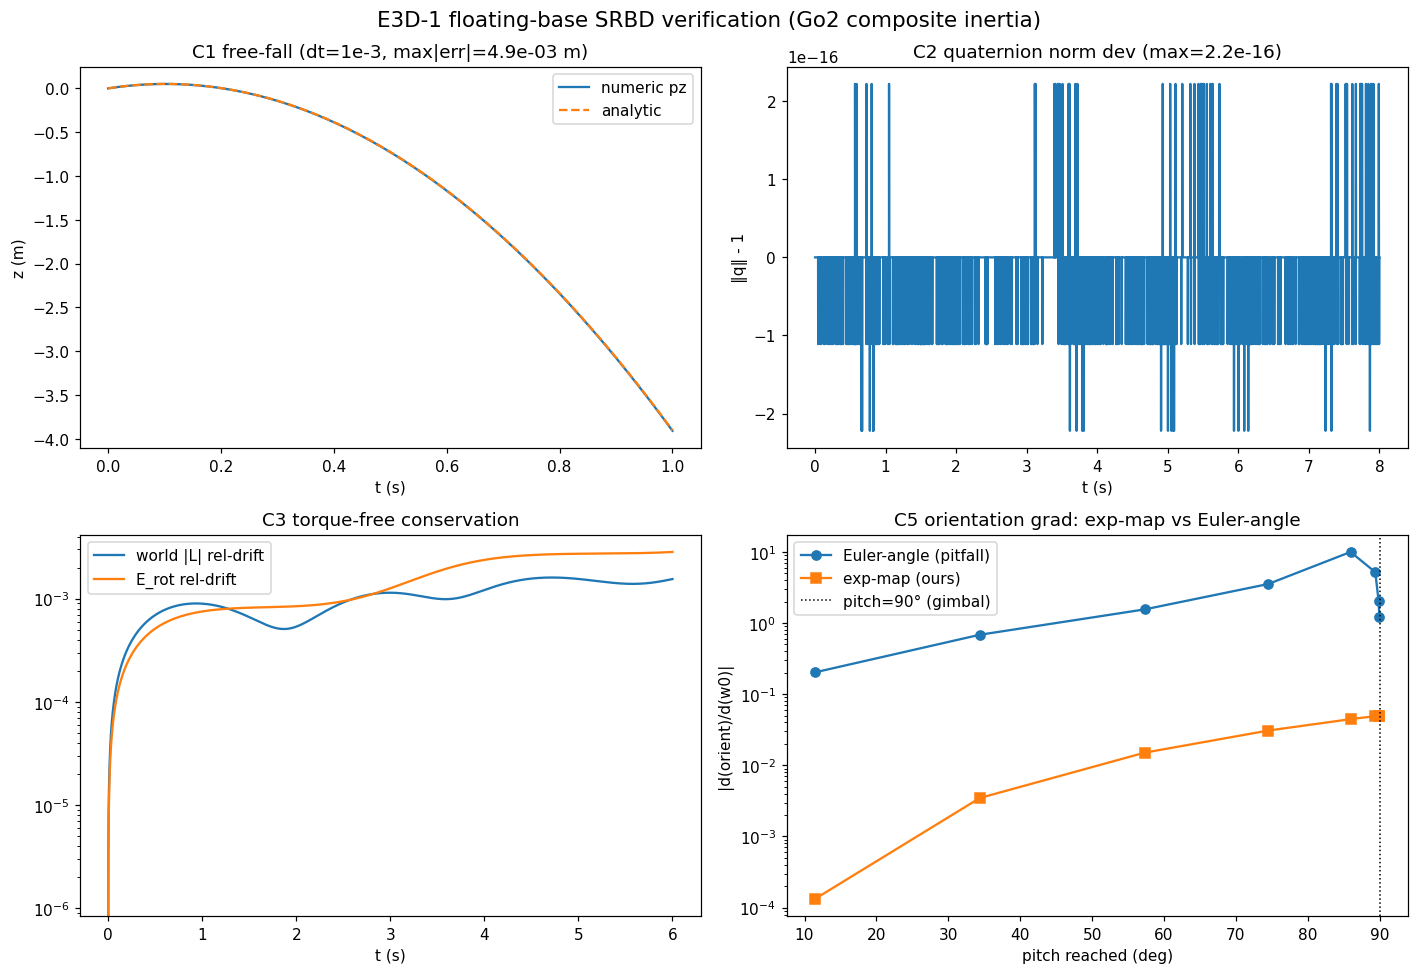

In [4]:
from IPython.display import Image
Image(str(ROOT / 'figures' / 'e3d1_floating_base_checks.png'))

## 3. 结论（E3D-1）
- **C1 坐标系/重力**：自由落体 pz 与解析吻合，误差随 dt 一阶收敛（dt 减半误差减半），速度精确到 1e-14。
- **C2 四元数**：8000 步后 `‖q‖−1 ≤ 2.2e-16`（机器精度）——姿态始终是合法单位四元数。
- **C3 frame/符号（最关键）**：力矩自由下**世界系角动量** L 与转动能相对漂移 ~1e-3 且**有界**——若 `w×(Iw)` 符号或四元数乘法顺序错，这里会发散。
- **C4 可微**：BPTT 梯度随视野温和增长（50→1600 步：0.09→2.0）不爆炸。
- **C5 踩坑确认**：欧拉角积分在 pitch→90° 处梯度爆炸（~200× 于 exp-map），exp-map 始终有界——**证明绝不能用欧拉角积分**。

floating-base 动力学层已钉死，可进入 E3D-2（足端 3D 平滑接触 + 摩擦锥）。